# IRIS - Connection II

![Add layer](https://github.com/DrKAI/image/blob/main/Add%20Layer.png?raw=true)

In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras

from sklearn.datasets import load_iris

## 데이터 불러오기
* iris.feature_names를 이용하여 판다스 데이터 프레임 만들기!

In [2]:
data=load_iris()

In [3]:
x=data.data
y=data.target

In [4]:
df=pd.DataFrame(x,columns=data.feature_names)

In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## train set, test set 구분하기

In [6]:
from sklearn.model_selection import train_test_split

In [40]:
x_train,x_test,y_train,y_test=train_test_split(df,y,random_state=2022,test_size=0.1)

In [41]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((135, 4), (15, 4), (135,), (15,))

## **sepal끼리, petal끼리**

In [42]:
x_tr_se=x_train.loc[:,['sepal length (cm)','sepal width (cm)']]
x_te_se=x_test.loc[:,['sepal length (cm)','sepal width (cm)']]

In [43]:
x_tr_pe=x_train.loc[:,['petal length (cm)','petal width (cm)']]
x_te_pe=x_test.loc[:,['petal length (cm)','petal width (cm)']]

## One-hot Encoding

In [44]:
from tensorflow.keras.utils import to_categorical

In [45]:
np.unique(y_train)

array([0, 1, 2])

In [46]:
y_train=to_categorical(y_train,3)
y_test=to_categorical(y_test,3)

## 스케일링

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler=MinMaxScaler()
# scaler.fit_transform(x_tr_pe)

In [57]:
x_tr_se.shape,x_tr_pe.shape,y_train.shape

((135, 2), (135, 2), (135, 3))

## Modeling : multi-input & Add layer

In [61]:
from tensorflow.python import metrics
keras.backend.clear_session()
il_s=keras.layers.Input((2,))
hl_s=keras.layers.Dense(4,activation='swish')(il_s)

il_p=keras.layers.Input((2,))
hl_p=keras.layers.Dense(4,activation='swish')(il_p)

co=keras.layers.Add()([hl_s,hl_p])
ol=keras.layers.Dense(3,activation='softmax')(co)

model=keras.models.Model(inputs=[il_s,il_p],outputs=ol)
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adam(),metrics=['Accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 2)]          0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 2)]          0           []                               
                                                                                                  
 dense (Dense)                  (None, 4)            12          ['input_1[0][0]']                
                                                                                                  
 dense_1 (Dense)                (None, 4)            12          ['input_2[0][0]']                
                                                                                              

## 모델 시각화

In [62]:
from tensorflow.keras.utils import plot_model

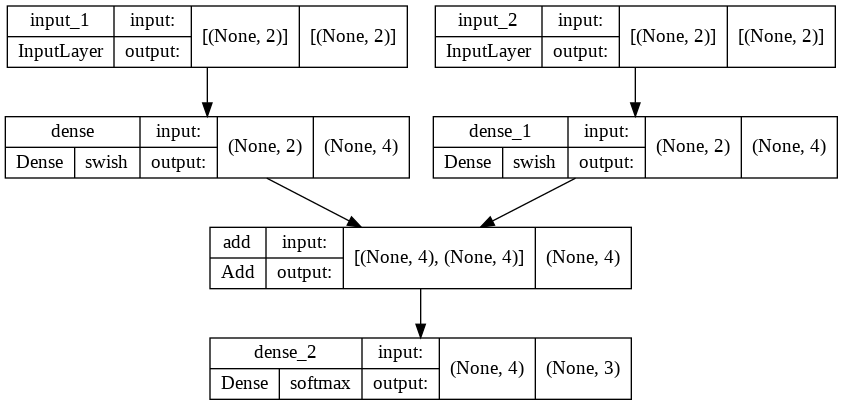

In [63]:
plot_model(model,show_layer_activations=True,show_shapes=True)

## 학습 시켜보기!

In [50]:
from tensorflow.keras.callbacks import EarlyStopping

In [51]:
es=EarlyStopping(verbose=1, patience=1, min_delta=0, restore_best_weights=True,monitor='val_loss')

In [64]:
model.fit([x_tr_se,x_tr_pe],y_train,verbose=1,epochs=1000,callbacks=[es],validation_split=0.2)

Epoch 1/1000
4/4 [==============================] - 1s 66ms/step - loss: 4.2359 - Accuracy: 0.3241 - val_loss: 3.8152 - val_Accuracy: 0.3704
Epoch 2/1000
4/4 [==============================] - 0s 10ms/step - loss: 4.0216 - Accuracy: 0.3241 - val_loss: 3.6136 - val_Accuracy: 0.3704
Epoch 3/1000
4/4 [==============================] - 0s 14ms/step - loss: 3.8017 - Accuracy: 0.3241 - val_loss: 3.4160 - val_Accuracy: 0.3704
Epoch 4/1000
4/4 [==============================] - 0s 10ms/step - loss: 3.5827 - Accuracy: 0.3241 - val_loss: 3.2240 - val_Accuracy: 0.3704
Epoch 5/1000
4/4 [==============================] - 0s 10ms/step - loss: 3.3850 - Accuracy: 0.3241 - val_loss: 3.0351 - val_Accuracy: 0.3704
Epoch 6/1000
4/4 [==============================] - 0s 10ms/step - loss: 3.1908 - Accuracy: 0.3241 - val_loss: 2.8545 - val_Accuracy: 0.3704
Epoch 7/1000
4/4 [==============================] - 0s 10ms/step - loss: 2.9984 - Accuracy: 0.3241 - val_loss: 2.6888 - val_Accuracy: 0.3704
Epoch 8/1000


In [67]:
score = model.evaluate([x_te_se,x_te_pe], y_test, verbose=0)

In [68]:
score

[0.5555254220962524, 0.7333333492279053]